<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 1. Predict failure risk from sensor data

In this notebook, I build a baseline model to flag rows that look risky.

Each row is one machine record. The target column is `fail`, where:

- `1` means failure
- `0` means no failure

The goal is practical. I use the available sensor and machine signals to estimate failure risk, then compare a small set of models to see which one is most useful once predictions are turned into actual failure flags.

By the end, I:

- prepare the labeled data
- compare several candidate models
- tune the decision threshold on validation data
- check the final result on the test set

A useful point in this notebook is that model selection is not finished once one model tops the cross validation table. Several models can remain viable, and the real differences may only show up after thresholding, when missed failures, false alarms, and review workload are all visible at the same time.

So the final choice is not only about which model scores highest. It is about which model fits the operating goal best.

</div>

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 2. Imports and settings

This section loads the libraries used in the rest of the notebook and sets the main run settings.

The constants at the bottom control the workflow:

- `TARGET = "fail"` tells the notebook which column to predict
- `RANDOM_STATE = 42` keeps the data split reproducible
- `TEST_SIZE = 0.20` keeps 20% of the rows for the final test set
- `CV_FOLDS = 5` uses five fold cross validation when screening models
- `VALIDATION_SIZE = 0.25` splits the remaining training data again so threshold choices are made on validation, not on test

So this block does not just import code. It fixes the setup the rest of the notebook will follow.

</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

TARGET = "fail"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
VALIDATION_SIZE = 0.25

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">
    
# 3. Load data

This section reads the labeled dataset into a dataframe.

The **predictor columns** are `footfall`, `tempMode`, `AQ`, `USS`, `CS`, `VOC`, `RP`, `IP`, and `Temperature`.


The target is `fail`.

The code below loads the file, checks that `fail` is present, and shows the first few rows so I can confirm the table loaded as expected before doing any cleaning or modeling.

</div>

In [2]:
def load_data(path: str, target: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    if target not in df.columns:
        raise ValueError(f"Missing target column: {target}")

    return df


DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
df = load_data(DATA_PATH, TARGET)

display(df.head())

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 4. Remove duplicates and do a quick data check

I remove exact duplicate rows before modeling, then check the cleaned table for missing values, class balance in `fail`, and feature scale.

Findings:
- one exact duplicate pattern in the raw data, so I remove it
- no missing values in the cleaned table
- `fail` is split about `58.3%` for `0` and `41.7%` for `1`

Because the target is not fully balanced, accuracy alone is not enough, so I also use `ROC AUC`, `average precision`, and `F1`.

Some features are on very different numeric scales, especially `footfall`. That mainly affects linear models, so later I scale them for Logistic Regression so larger values do not dominate the fit more than the actual pattern.

</div>

In [3]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Original shape: {df.shape}")

if duplicate_rows.empty:
    print("Duplicate rows found: 0")
else:
    print(f"Duplicate rows found: {len(duplicate_rows)}")
    display(duplicate_rows.reset_index())

df = df.drop_duplicates().reset_index(drop=True)

target_counts = df[TARGET].value_counts().sort_index()
target_props = df[TARGET].value_counts(normalize=True).sort_index()

print(f"\nCleaned shape: {df.shape}")
print(f"Missing values: {int(df.isnull().sum().sum())}")

print("\nTarget distribution")
for label, count in target_counts.items():
    print(f"{label}: {count:,} ({target_props[label]:.1%})")

summary = (
    df.drop(columns=[TARGET])
      .describe()
      .T[["min", "50%", "max"]]
      .rename(columns={"50%": "median"})
)

display(summary)

Original shape: (944, 10)
Duplicate rows found: 2


,index,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,730,31,5,3,3,6,1,48,6,21,0
1,766,31,5,3,3,6,1,48,6,21,0



Cleaned shape: (943, 10)
Missing values: 0

Target distribution
0: 550 (58.3%)
1: 393 (41.7%)


,min,median,max
footfall,0.0,22.0,7300.0
tempMode,0.0,3.0,7.0
AQ,1.0,4.0,7.0
USS,1.0,3.0,7.0
CS,1.0,6.0,7.0
VOC,0.0,2.0,6.0
RP,19.0,44.0,91.0
IP,1.0,4.0,7.0
Temperature,1.0,17.0,24.0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 5. Separate predictors and target

Here, I split the cleaned table into inputs and labels.

- `X` holds the predictor columns
- `y` holds the target column, `fail`

This is a small step, but it sets up everything that follows. The train, validation, and test split is done from `X` and `y`, and every model later in the notebook is fit on that same separation.

</div>

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 6. Build train, validation, and test sets

This section gives each split a separate job.

The code first holds out the test set. Then it splits the remaining rows again to create a validation set.

That leaves three parts:

- training set for fitting and comparing models
- validation set for choosing thresholds
- test set for the final check only

This split matters because the notebook is not only comparing models. It is also choosing a decision threshold later. That threshold needs to be chosen on validation data, not on the final test set.

The table below shows how many rows end up in each split and whether the failure rate stays similar across them. That is a quick check that the split is reasonable before model training starts.

</div>

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

split_summary = pd.DataFrame({
    "set": ["full data", "train", "validation", "test"],
    "rows": [len(y), len(y_train), len(y_val), len(y_test)],
    "failure rate": [y.mean(), y_train.mean(), y_val.mean(), y_test.mean()]
})

split_summary["failure rate"] = split_summary["failure rate"].map(lambda v: f"{v:.1%}")
display(split_summary)

,set,rows,failure rate
0,full data,943,41.7%
1,train,565,41.6%
2,validation,189,41.8%
3,test,189,41.8%


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 7. Train a few models, then carry the top two forward

I start by comparing a small set of models on the training split with cross validation.

The table below is only a first screen. It shows the average cross validation scores for each model, so I can see which ones are strong enough to keep.

I do not stop at a single winner here. Instead, I carry the top two models forward and fit both on the full training split.

I do that for a simple reason: the best cross validation score does not always lead to the best final operating result. Two models can look close here, then behave differently later once probabilities are turned into actual failure flags.

So this section does two things:

- rank the candidate models on the training split
- keep the top two for the validation and test comparison that comes next

</div>

In [6]:
def build_pipeline(model_name):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])

    if model_name == "Random Forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "Extra Trees":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "HistGradientBoosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_depth=4,
                learning_rate=0.05,
                max_iter=250,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "SVM RBF":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "XGBoost":
        if not HAS_XGBOOST:
            raise ValueError("XGBoost is not installed in this runtime")
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0
            ))
        ])

    raise ValueError(f"Unknown model: {model_name}")


candidate_models = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
    "SVM RBF",
]

if HAS_XGBOOST:
    candidate_models.append("XGBoost")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
benchmark_rows = []

for model_name in candidate_models:
    candidate_pipeline = build_pipeline(model_name)

    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc", "average_precision", "f1"],
        n_jobs=-1,
        error_score="raise"
    )

    benchmark_rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "avg_precision": scores["test_average_precision"].mean(),
        "f1": scores["test_f1"].mean()
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["avg_precision", "roc_auc"], ascending=False)
    .reset_index(drop=True)
    .round(3)
)

display(benchmark_table)

top_models = benchmark_table.loc[:1, "model"].tolist()
model_pipelines = {}

for model_name in top_models:
    pipeline = build_pipeline(model_name)
    pipeline.fit(X_train, y_train)
    model_pipelines[model_name] = pipeline

print("Models carried forward:")
for model_name in top_models:
    print(f"- {model_name}")

,model,accuracy,roc_auc,avg_precision,f1
0,SVM RBF,0.912,0.972,0.964,0.892
1,Extra Trees,0.915,0.972,0.963,0.900
2,Random Forest,0.920,0.969,0.962,0.906
3,Logistic Regression,0.915,0.973,0.961,0.898
4,HistGradientBoosting,0.901,0.960,0.948,0.880
5,XGBoost,0.904,0.962,0.947,0.886


Models carried forward:
- SVM RBF
- Extra Trees


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 8. Check validation performance for both models

This is the first comparison between the two models on unseen rows. At this stage, both are still using their default cutoff.

Extra Trees does better here because it finds more failure rows without adding much extra noise: 
- It catches 70 of the 79 failures in the validation split, while SVM RBF catches 67.
- The false alarm count is almost the same, 15 for Extra Trees and 14 for SVM RBF.

That is why the gap shows up mostly in recall and F1, not precision. SVM RBF is only slightly more selective, but that small gain is not enough to make up for the 3 extra missed failures.

So the validation result is simple: before any threshold tuning, Extra Trees is using the failure signal a bit more effectively.

</div>

,model,accuracy,roc_auc,avg_precision,precision,recall,f1,false_alarms,missed_failures,flagged_rows
0,SVM RBF,0.862,0.947,0.948,0.827,0.848,0.838,14,12,81
1,Extra Trees,0.873,0.946,0.947,0.824,0.886,0.854,15,9,85


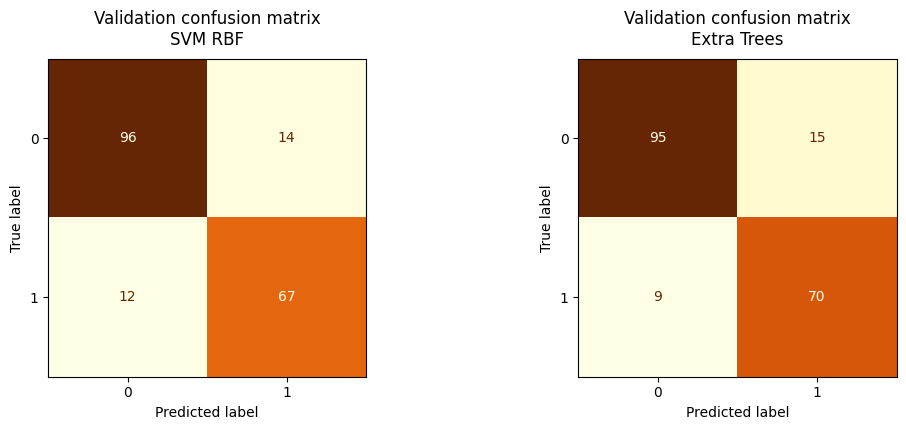

In [7]:
validation_rows = []
validation_outputs = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    y_val_pred_default = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_default).ravel()

    validation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_val_pred_default),
        "roc_auc": roc_auc_score(y_val, y_val_proba),
        "avg_precision": average_precision_score(y_val, y_val_proba),
        "precision": precision_score(y_val, y_val_pred_default, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_default, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_default, zero_division=0),
        "false_alarms": int(fp),
        "missed_failures": int(fn),
        "flagged_rows": int(tp + fp),
    })

    validation_outputs[model_name] = {
        "y_pred": y_val_pred_default,
        "y_proba": y_val_proba
    }

validation_metrics = pd.DataFrame(validation_rows).round(3)
display(validation_metrics)

fig, axes = plt.subplots(1, len(top_models), figsize=(11, 4.4))

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        validation_outputs[model_name]["y_pred"],
        cmap="YlOrBr",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Validation confusion matrix\n{model_name}", pad=10)

plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 9. Check which variables matter most for each model

This section shows whether the two models are finding different patterns in the sensor data, or mostly the same one.

They are mostly finding the same one.

In both models, VOC is the main feature by a wide margin. USS is second. AQ and CS still help, but much less. Everything after that has little effect on ROC AUC when shuffled.

So the two models are not separated by feature discovery. They are reading almost the same signal. The main difference comes later, in how each model turns that signal into final failure labels.

</div>

,feature,SVM RBF | importance,SVM RBF | tier,Extra Trees | importance,Extra Trees | tier
0,VOC,0.2065,high,0.2152,high
1,USS,0.0448,medium,0.0406,medium
2,AQ,0.0260,medium,0.0299,medium
3,CS,0.0209,medium,0.0177,medium
4,footfall,0.0083,low,0.0021,low
5,RP,0.0018,low,-0.0021,low
6,IP,0.0010,low,-0.0001,low
7,Temperature,0.0002,low,-0.0025,low
8,tempMode,-0.0014,low,-0.0005,low


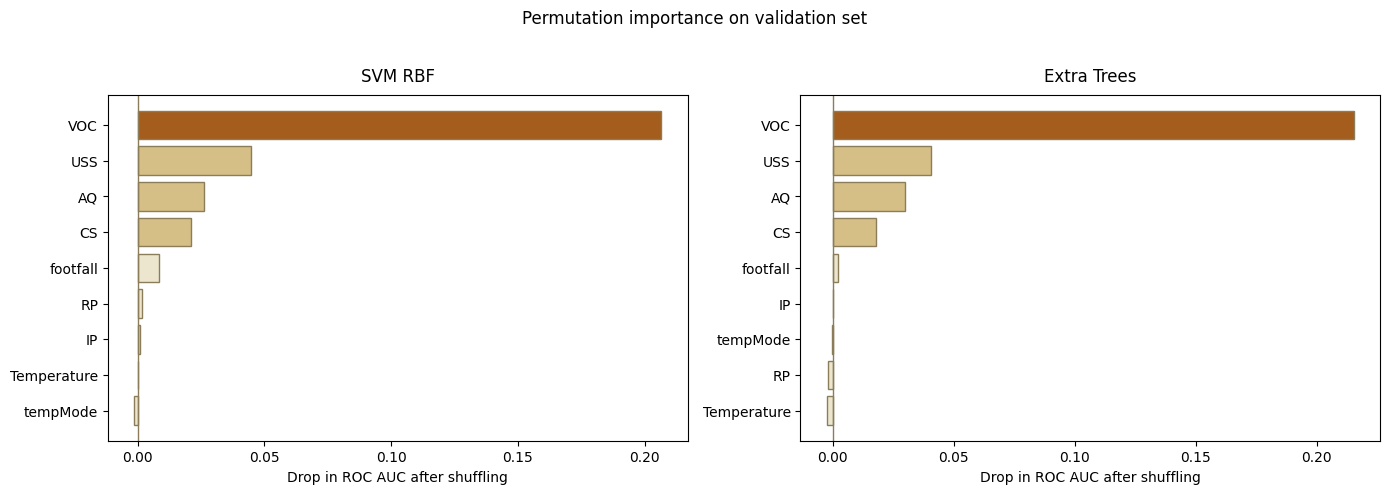

In [8]:
importance_results = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    perm = permutation_importance(
        pipeline,
        X_val,
        y_val,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="roc_auc",
        n_jobs=-1,
    )

    importance_table = (
        pd.DataFrame({
            "feature": X_val.columns,
            "importance": perm.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
        .round(4)
    )

    def assign_importance_tier(value):
        if value >= 0.05:
            return "high"
        if value >= 0.01:
            return "medium"
        return "low"

    importance_table["tier"] = importance_table["importance"].apply(assign_importance_tier)

    importance_results[model_name] = importance_table

display(
    pd.concat(
        [importance_results[name].set_index("feature")[["importance", "tier"]].add_prefix(f"{name} | ") for name in top_models],
        axis=1
    ).reset_index()
)

tier_colors = {
    "low": "#ece6cf",
    "medium": "#d6bf86",
    "high": "#a55d1d",
}

fig, axes = plt.subplots(1, len(top_models), figsize=(14, 4.8), sharex=False)

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    importance_table = importance_results[model_name]
    bar_colors = importance_table["tier"].map(tier_colors)

    ax.barh(
        importance_table["feature"],
        importance_table["importance"],
        color=bar_colors,
        edgecolor="#8b7d5a",
        linewidth=1.0,
    )
    ax.axvline(0, color="#8b7d5a", linewidth=1)
    ax.set_title(model_name, pad=10)
    ax.set_xlabel("Drop in ROC AUC after shuffling")
    ax.set_ylabel("")
    ax.invert_yaxis()

plt.suptitle("Permutation importance on validation set", y=1.02)
plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 10. Choose a threshold for each model, then compare final test results

The validation comparison above used the default cutoff. This section replaces that with a threshold chosen for the actual operating goal.

For each model, I pick the threshold on the validation split using the same rule:

- keep recall at or above 0.90 when possible
- keep alert rate at or below 50% when possible
- among those thresholds, keep the one with the lowest cost
- one missed failure counts as 10 false alarms

That changes both models in the same direction. Lowering the cutoff makes them catch more failures, but it also raises the number of alerts.

After thresholding, Extra Trees ends up at 0.216 and SVM RBF at 0.195. On the test set, Extra Trees misses only 1 failure, but it raises 25 false alarms. SVM RBF misses 2 failures and raises 19 false alarms.

So this is the final tradeoff:

- Extra Trees gains 1 extra true failure
- SVM RBF avoids 6 false alarms

Everything else is secondary to that. ROC AUC is almost the same for both, so ranking quality is not the real separator here. The decision comes from what happens after the threshold is applied.

At this point, the choice comes down to one question: is it worse to miss 1 extra failure, or to review 6 extra false alarms.

</div>

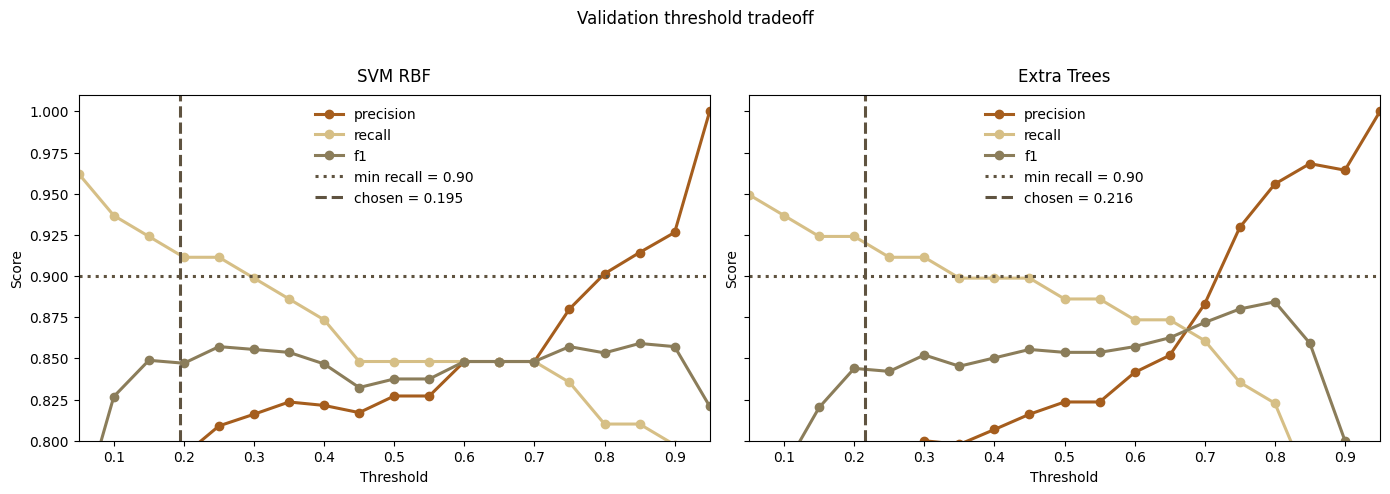

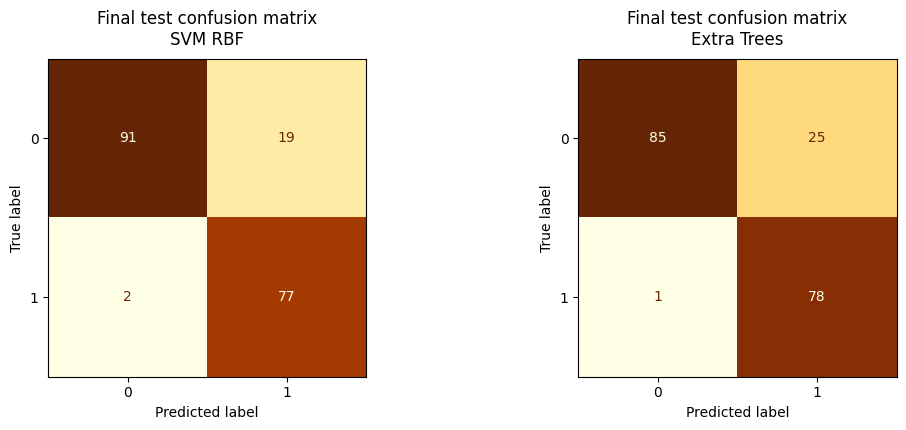

,model,threshold,accuracy,roc_auc,avg_precision,precision,recall,f1,false_alarms,missed_failures,flagged_rows,alert_rate,cost,selection_note
0,Extra Trees,0.216,0.862,0.975,0.963,0.757,0.987,0.857,25,1,103,0.545,35,"met recall target and workload limit, then gav..."
1,SVM RBF,0.195,0.889,0.976,0.959,0.802,0.975,0.880,19,2,96,0.508,39,"met recall target and workload limit, then gav..."


Lower cost option on the final test set: Extra Trees


In [9]:
min_recall = 0.90
false_negative_cost = 10
false_positive_cost = 1
max_alert_rate = 0.50

def evaluate_threshold(y_true, y_score, threshold):
    pred_t = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred_t).ravel()

    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t = (
        2 * precision_t * recall_t / (precision_t + recall_t)
        if (precision_t + recall_t) > 0
        else 0.0
    )

    alerts = int(tp + fp)
    alert_rate = alerts / len(y_true)
    expected_cost = (fn * false_negative_cost) + (fp * false_positive_cost)

    return {
        "threshold": float(threshold),
        "precision": precision_t,
        "recall": recall_t,
        "f1": f1_t,
        "false_alarms": int(fp),
        "missed_failures": int(fn),
        "alerts": alerts,
        "alert_rate": alert_rate,
        "cost": expected_cost,
    }

final_rows = []
threshold_plots = {}
test_outputs = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    candidate_thresholds = np.unique(np.round(y_val_proba, 6))

    threshold_table = (
        pd.DataFrame([evaluate_threshold(y_val, y_val_proba, t) for t in candidate_thresholds])
        .sort_values("threshold")
        .reset_index(drop=True)
    )

    eligible = threshold_table[
        (threshold_table["recall"] >= min_recall) &
        (threshold_table["alert_rate"] <= max_alert_rate)
    ].copy()

    if not eligible.empty:
        chosen_row = (
            eligible
            .sort_values(["cost", "false_alarms", "threshold"], ascending=[True, True, False])
            .iloc[0]
        )
        chosen_reason = "met recall target and workload limit, then gave the lowest cost"
    else:
        chosen_row = (
            threshold_table
            .sort_values(["cost", "recall", "threshold"], ascending=[True, False, False])
            .iloc[0]
        )
        chosen_reason = "no threshold met both rules, so the lowest cost option was used"

    chosen_threshold = float(chosen_row["threshold"])

    plot_thresholds = np.arange(0.05, 1.00, 0.05)
    plot_table = pd.DataFrame([evaluate_threshold(y_val, y_val_proba, t) for t in plot_thresholds])

    threshold_plots[model_name] = {
        "plot_table": plot_table,
        "chosen_threshold": chosen_threshold,
    }

    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= chosen_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    accuracy = accuracy_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    avg_precision = average_precision_score(y_test, y_test_proba)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    test_alerts = int(tp + fp)
    test_alert_rate = test_alerts / len(y_test)
    test_cost = (fn * false_negative_cost) + (fp * false_positive_cost)

    final_rows.append({
        "model": model_name,
        "threshold": chosen_threshold,
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "avg_precision": avg_precision,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": int(fp),
        "missed_failures": int(fn),
        "flagged_rows": test_alerts,
        "alert_rate": test_alert_rate,
        "cost": test_cost,
        "selection_note": chosen_reason,
    })

    test_outputs[model_name] = {
        "y_pred": y_test_pred
    }

fig, axes = plt.subplots(1, len(top_models), figsize=(14, 4.8), sharey=True)

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    plot_table = threshold_plots[model_name]["plot_table"]
    chosen_threshold = threshold_plots[model_name]["chosen_threshold"]

    ax.plot(
        plot_table["threshold"],
        plot_table["precision"],
        marker="o",
        linewidth=2.2,
        color="#a55d1d",
        label="precision",
    )
    ax.plot(
        plot_table["threshold"],
        plot_table["recall"],
        marker="o",
        linewidth=2.2,
        color="#d6bf86",
        label="recall",
    )
    ax.plot(
        plot_table["threshold"],
        plot_table["f1"],
        marker="o",
        linewidth=2.2,
        color="#8b7d5a",
        label="f1",
    )
    ax.axhline(
        min_recall,
        color="#5f5340",
        linestyle=":",
        linewidth=2.2,
        label=f"min recall = {min_recall:.2f}",
    )
    ax.axvline(
        chosen_threshold,
        color="#5f5340",
        linestyle="--",
        linewidth=2.2,
        label=f"chosen = {chosen_threshold:.3f}",
    )
    ax.set_title(model_name, pad=10)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0.80, 1.01)
    ax.set_xlim(0.05, 0.95)
    ax.legend(frameon=False)

plt.suptitle("Validation threshold tradeoff", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(top_models), figsize=(11, 4.4))

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_outputs[model_name]["y_pred"],
        cmap="YlOrBr",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Final test confusion matrix\n{model_name}", pad=10)

plt.tight_layout()
plt.show()

final_results = pd.DataFrame(final_rows).sort_values(
    ["cost", "missed_failures", "false_alarms"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(final_results.round({
    "threshold": 3,
    "accuracy": 3,
    "roc_auc": 3,
    "avg_precision": 3,
    "precision": 3,
    "recall": 3,
    "f1": 3,
    "alert_rate": 3,
    "cost": 1
}))

best_by_cost = final_results.iloc[0]["model"]
print(f"Lower cost option on the final test set: {best_by_cost}")

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 11. Final takeaway

This is the part that matters most to me: the cross validation table was useful for narrowing the field, but it was not enough to make the final choice.

Once I carried both models forward, set their thresholds on the validation split, and checked them on the test set, the difference became much easier to read.

Extra Trees is the recall first option. It misses only 1 failure, but that gain comes with 25 false alarms.

SVM RBF is the baseline I would keep. It misses 2 failures instead of 1, but it cuts false alarms down to 19 and finishes with better precision and F1.

So I would use the models this way:

- SVM RBF as the default model when I want a stronger balance between failure detection and review load
- Extra Trees as the fallback when missing as few failures as possible matters more than the extra alerts

That is the main lesson from this notebook. In practice, the final model choice is not just about which model tops the first ranking table. It is about what happens after thresholding, when missed failures and false alarms become a real operating tradeoff.

</div>